# ULYSSES — Universal LeptogeneSiS Equation Solver

This notebook demonstrates how to use ULYSSES directly from Python without the command-line tools.
We cover four representative scenarios:

1. **1BE1F** — vanilla unflavoured leptogenesis (1 decaying heavy neutrino, single-flavour approximation)
2. **1DME** — density matrix equations, fully flavoured leptogenesis, 1 decaying heavy neutrino
3. **ARS_3RHN** — low-scale leptogenesis via oscillation with 3 RHNs
4. **1BE1F_DM_FreezeIn** — 1BE1F leptogenesis extended with a FIMP dark matter sector

All parameters are passed as plain Python dicts — no runcard files needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import zeta

import ulysses

# Useful conversion constants (PDG 2020)
_gstar0   = 43.0 / 11.0          # entropic g* today
_ToYb     = 45 * zeta(3) / (_gstar0 * np.pi**4)
_ngamma   = 410.7                 # photon number density today [cm^-3]
_mp       = 1.672621898e-24       # proton mass [g]
_rhoc     = 1.87840e-29           # critical density h^2 [g cm^-3]
_ToOmegab = _mp * _ngamma / _rhoc

print("ULYSSES loaded. Available models:")
for name in sorted(ulysses.getBuiltInModels().keys()):
    print(" ", name)

ULYSSES loaded. Available models:
  1BE1F
  1BE1F_Case2
  1BE1F_Case3
  1BE1F_Case4
  1BE1F_CaseS2
  1BE1F_DM_FreezeIn
  1BE1F_PBH
  1BE1Fsf
  1BE2F
  1BE3F
  1DME
  2BE1F
  2BE2F
  2BE3F
  2DME
  2RES
  2RESmix
  2RESsp
  3DME
  3DMEsct
  BEARS
  BEARS_3RHN
  BEARS_INTERP


---
## Helper: evolution plot

A simple plotting function used by all scenarios below.

In [2]:
def _auto_ylim(ax, low_pct=2, margin=0.5, top_margin=0.2):
    """Tight log-scale y-limits, ignoring sign-change transients and reference lines."""
    data_log, ref_log = [], []
    for line in ax.get_lines():
        y = np.asarray(line.get_ydata(), dtype=float)
        y = y[np.isfinite(y) & (y > 0)]
        if not len(y):
            continue
        if np.ptp(y) == 0:
            ref_log.append(np.log10(y[0]))
        else:
            data_log.append(np.log10(y))
    if not data_log:
        return
    all_data = np.concatenate(data_log)
    lower = np.percentile(all_data, low_pct) - margin
    upper = max(np.max(all_data), max(ref_log, default=-np.inf))
    ax.set_ylim([10**lower, 10**(upper + top_margin)])


def plot_evolution(L, title="", figsize_single=(8, 5), figsize_double=(8, 8)):
    """Plot the ODE evolution stored in L after calling L(params)."""
    data     = L.evolData
    active   = L.flavourindices()
    labels   = L.flavourlabels()
    ext      = L.extendedindices()
    extlab   = L.extendedlabels()
    xlabel   = getattr(L, 'evolname', 'z')
    lw       = 1.5

    if ext:
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=figsize_double)
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=figsize_single)

    # --- upper panel: flavour abundances + eta_B ---
    for idx, lab in zip(active, labels):
        vals  = data[:, idx]
        line, = ax1.plot(data[:, 0], np.abs(vals), label=lab, linewidth=lw)
        neg   = np.where(vals < 0, np.abs(vals), np.nan)
        if not np.all(np.isnan(neg)):
            ax1.plot(data[:, 0], neg, linestyle='--', color=line.get_color(), linewidth=lw)

    ax1.axhline(6.1e-10, color='grey', linewidth=0.8, linestyle=':', label=r"$\eta_B^{\rm obs}$")
    ax1.plot(data[:, 0], np.abs(data[:, -1]), label=r"$|\eta_B|$", linewidth=lw, color='k')
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,
               shadow=True, prop={'size': 11})
    ax1.set_yscale("log"); ax1.set_xscale("log")
    ax1.set_ylabel(r"$\left|N_{xx}\right|,\,\eta_B$", fontsize=13)
    ax1.tick_params(direction='in', which='both', labelsize=12, width=0.8)
    ax1.xaxis.set_ticks_position('both'); ax1.yaxis.set_ticks_position('both')
    ax1.grid(which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.2)
    _auto_ylim(ax1)
    if title:
        ax1.set_title(title, fontsize=13)
    if not ext:
        ax1.set_xlabel(xlabel, fontsize=13)

    # --- lower panel: extended quantities ---
    if ext:
        for idx, lab in zip(ext, extlab):
            vals  = data[:, idx]
            line, = ax2.plot(data[:, 0], np.abs(vals), label=lab, linewidth=lw)
            neg   = np.where(vals < 0, np.abs(vals), np.nan)
            if not np.all(np.isnan(neg)):
                ax2.plot(data[:, 0], neg, linestyle='--', color=line.get_color(), linewidth=lw)
        ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,
                   shadow=True, prop={'size': 11})
        ax2.set_yscale("log"); ax2.set_xscale("log")
        ax2.set_xlabel(xlabel, fontsize=13)
        ax2.set_ylabel(r"$\left|N_{\rm ext}\right|$", fontsize=13)
        ax2.tick_params(direction='in', which='both', labelsize=12, width=0.8)
        ax2.xaxis.set_ticks_position('both'); ax2.yaxis.set_ticks_position('both')
        ax2.grid(which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.2)
        _auto_ylim(ax2)

    plt.tight_layout()
    plt.show()

---
## 1. Unflavoured leptogenesis — `1BE1F`

The simplest single-RHN scenario: one Boltzmann equation for $N_1$ and one for $N_{B-L}$,
neglecting flavour effects.  We use the Casas–Ibarra parametrisation (`euler`).

Parameters are given as logarithms where noted:
- `m` — lightest neutrino mass $\log_{10}(m_{\rm lightest}/\text{eV})$
- `M1`, `M2`, `M3` — RHN masses $\log_{10}(M_i/\text{GeV})$
- `delta`, `a21`, `a31` — Dirac and Majorana phases [deg]
- `x1, y1, x2, y2, x3, y3` — Euler angles in $R$ matrix [deg]
- `t12`, `t13`, `t23` — PMNS mixing angles [deg]

In [3]:
params_1BE1F = {
    'm'    : -100,   # effectively massless lightest neutrino
    'M1'   : 14,     # M1 = 10^14 GeV
    'M2'   : 15,
    'M3'   : 16,
    'delta': 270,
    'a21'  : 0,
    'a31'  : 0,
    'x1'   : 180,
    'y1'   : 1.4,
    'x2'   : 180,
    'y2'   : 11.2,
    'x3'   : 180,
    'y3'   : 11,
    't12'  : 33.82,
    't13'  : 8.61,
    't23'  : 49.7,
}

L1 = ulysses.selectModel('1BE1F', zmin=0.1, zmax=100, zsteps=1000,
                          ordering=0, loop=False)

etaB = L1(params_1BE1F)

print(f"eta_B      = {etaB:.6e}")
print(f"Y_B        = {etaB * _ToYb:.6e}")
print(f"Omega_b h2 = {etaB * _ToOmegab:.6e}")
print(f"(observed eta_B ~ 6.1e-10)")

-9.800660509812999e-05 4.1552288193783655e-07
eta_B      = 6.097035e-10
Y_B        = 8.661258e-11
Omega_b h2 = 2.229734e-02
(observed eta_B ~ 6.1e-10)


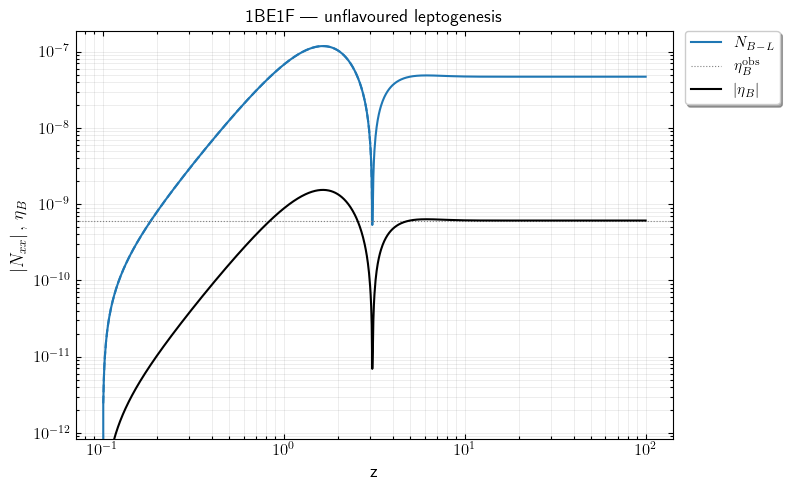

In [4]:
plot_evolution(L1, title="1BE1F — unflavoured leptogenesis")

---
## 2. Flavoured leptogenesis — `1DME`

Density matrix equations tracking lepton asymmetries in each SM flavour separately
(tau, mu, e).  Flavour effects become important for $M_1 \lesssim 10^{12}$ GeV.
Same Casas–Ibarra parametrisation as 1BE1F.

In [16]:
params_1DME = {
    'm'    : -0.60206,   # m ~ 0.25 eV (quasi-degenerate)
    'M1'   : 11,         # M1 = 10^11 GeV — in the flavoured regime
    'M2'   : 12,
    'M3'   : 15,
    'delta': 270,
    'a21'  : 0,
    'a31'  : 0,
    'x1'   : 45,
    'y1'   : 45,
    'x2'   : 45,
    'y2'   : 45,
    'x3'   : 45,
    'y3'   : 45,
    't12'  : 33.63,
    't13'  : 8.52,
    't23'  : 48.7,
}

L2 = ulysses.selectModel('1DME', zmin=0.1, zmax=100, zsteps=1000,
                          ordering=0, loop=False, initial_abundance = 0)

etaB = L2(params_1DME)

print(f"eta_B      = {etaB:.6e}")
print(f"Y_B        = {etaB * _ToYb:.6e}")
print(f"Omega_b h2 = {etaB * _ToOmegab:.6e}")

eta_B      = -1.020307e-09
Y_B        = -1.449417e-10
Omega_b h2 = -3.731345e-02


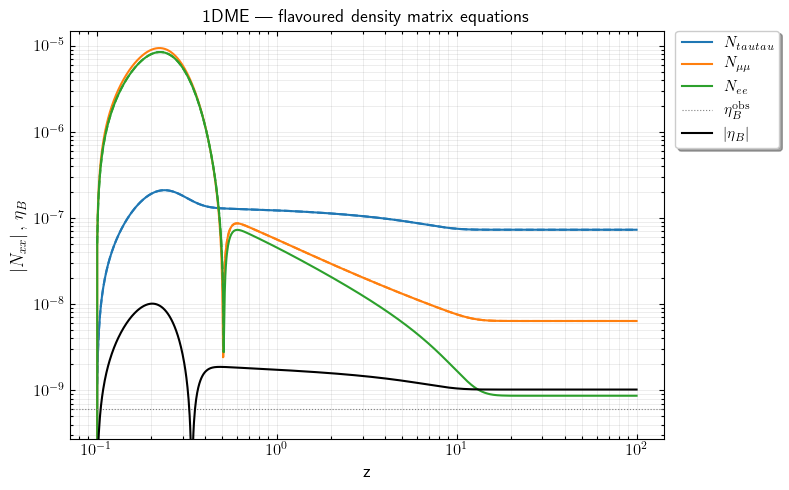

In [17]:
plot_evolution(L2, title="1DME — flavoured density matrix equations")

---
## 3. Low-scale leptogenesis via oscillations — `ARS_3RHN`

Low-scale leptogenesis via oscillations between nearly
degenerate RHNs (Akhmedov–Rubakov–Smirnov mechanism). We use the alternative Casas–Ibarra parametrisation (`single-imaginary`).


The evolution variable here is $T_{\rm sph}/T$ rather than $z = M/T$.

In [3]:
params_ARS = {
    'm'   : -100,
    'M1'  : 1.00003833,   # log10(M1/GeV) — near 10 GeV, quasi-degenerate
    'M2'  : 1.00002833,
    'M3'  : 0.99993333,
    'xnu1': 4,
    'xnu2': 5,
    'xN1' : 2,
    'xN2' : 3,
    'x'   : 1,
    'y'   : 103.13240312354819,
    'delta': 0.0,
    'a21' : 0,
    'a31' : 0,
    't23' : 49.49,
    't12' : 33.41,
    't13' : 8.58,
}

L3 = ulysses.selectModel('BEARS_3RHN', zmin=0.1, zmax=100, zsteps=1000,
                          ordering=0, loop=True, zcut=1.0)

L3.which_param = 'single_imaginary'

etaB = L3(params_ARS)

print(f"eta_B      = {etaB:.6e}")
print(f"Y_B        = {etaB * _ToYb:.6e}")
print(f"Omega_b h2 = {etaB * _ToOmegab:.6e}")

eta_B      = 1.453152e-10
Y_B        = 2.064302e-11
Omega_b h2 = 5.314291e-03


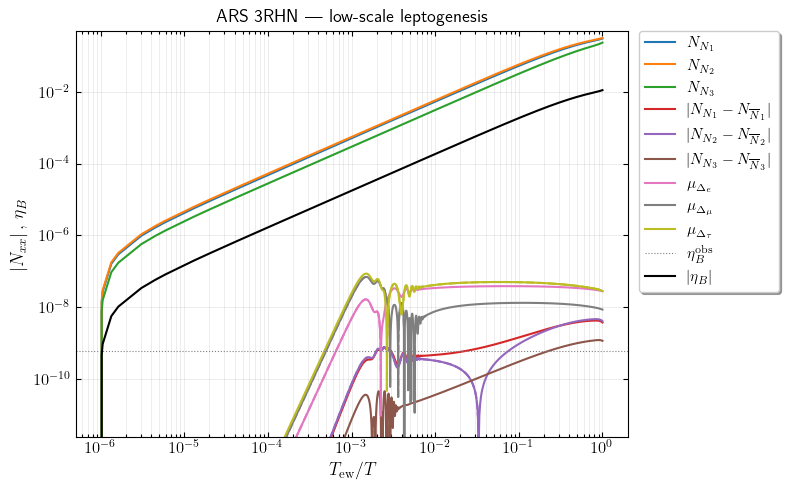

In [4]:
plot_evolution(L3, title="ARS 3RHN — low-scale leptogenesis")

---
## 4. Freeze-in dark matter + leptogenesis — `1BE1F_DM_FreezeIn`

Extends 1BE1F by adding a third Boltzmann equation for a FIMP dark matter particle
produced via rare $N_1 \to X\bar{X}$ decays with dark coupling $\lambda$.

Two extra runcard parameters:
- `lam` — dark sector coupling (dimensionless)
- `m_dm` — DM mass in GeV

These are passed alongside the standard 1BE1F parameters using `--extended` mode
(or `extended_mode=True` in Python).

In [5]:
params_DM = {
    # Standard 1BE1F parameters
    'm'    : -100,
    'M1'   : 12,
    'M2'   : 15,
    'M3'   : 16,
    'delta': 270,
    'a21'  : 0,
    'a31'  : 0,
    'x1'   : 180,
    'y1'   : 1.4,
    'x2'   : 180,
    'y2'   : 11.2,
    'x3'   : 180,
    'y3'   : 11,
    't12'  : 33.82,
    't13'  : 8.61,
    't23'  : 49.7,
    # Dark sector extensions
    'lam'  : 1e-7,    # FIMP coupling — tune to hit Omega h^2 ~ 0.12
    'm_dm' : 1e11,    # DM mass [GeV] — chosen so N_DM^eq drops visibly in z in [0.1,100]
}

L4 = ulysses.selectModel('1BE1F_DM_FreezeIn', zmin=0.1, zmax=100, zsteps=1000,
                          ordering=0, loop=False, extended_mode=True)

etaB = L4(params_DM)

print(f"eta_B        = {etaB:.6e}")
print(f"Y_B          = {etaB * _ToYb:.6e}")
print(f"Y_DM         = {L4.dmYield:.6e}")
print(f"Omega_DM h^2 = {L4.OmDMh2:.6e}   (observed ~ 0.12)")

eta_B        = -5.939501e-14
Y_B          = -8.437470e-15
Y_DM         = 2.631295e-12
Omega_DM h^2 = 7.219823e+07   (observed ~ 0.12)


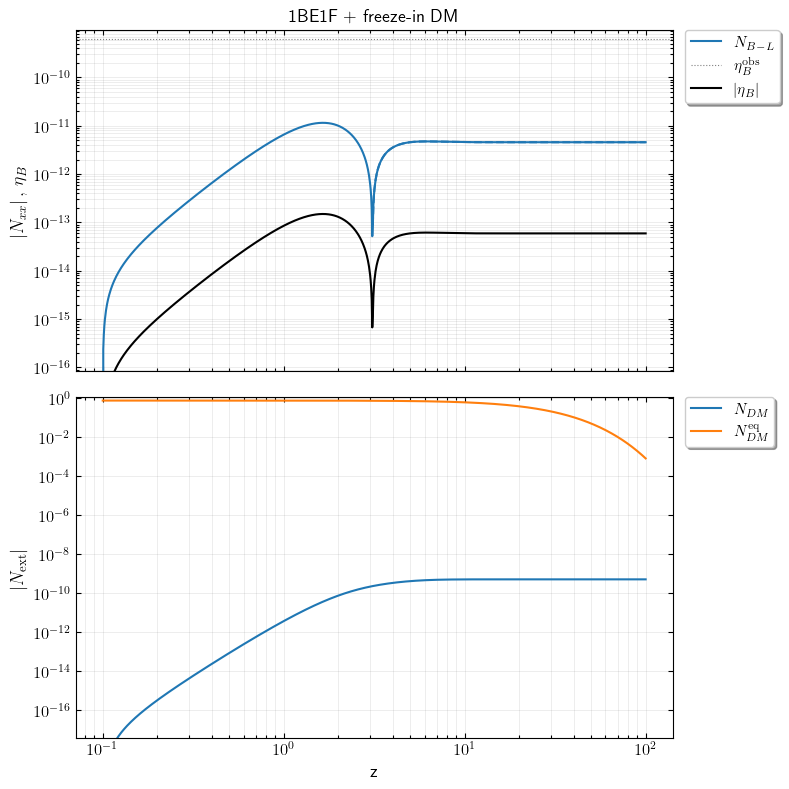

In [6]:
plot_evolution(L4, title="1BE1F + freeze-in DM")

---
## 5. Scanning over a parameter

A quick example of looping over a parameter in pure Python — no runcard scanning tools needed.

-9.80066050981299e-09 4.15522881937926e-11
-1.3966947463267723e-08 5.921627686210575e-11
-1.9904334125884407e-08 8.438927428173315e-11
-2.8365719713400937e-08 1.2026338012381438e-10
-4.042406290863407e-08 1.7138766415404363e-10
-5.760843999559089e-08 2.4424501784293506e-10
-8.209794166970416e-08 3.4807422713808003e-10
-1.169979958998784e-07 4.960415105554846e-10
-1.6673415637701571e-07 7.069100812738953e-10
-2.3761329148465322e-07 1.00741944408581e-09
-3.386233361942536e-07 1.4356761398897442e-09
-4.82573020633092e-07 2.0459859022675314e-09
-6.877161003234408e-07 2.9157399715610087e-09
-9.800660509812983e-07 4.155228819381669e-09
-1.3966947463267623e-06 5.921627686217405e-09
-1.9904334125884432e-06 8.438927428167598e-09
-2.8365719713400953e-06 1.2026338012377361e-08
-4.042406290845571e-06 1.7138766422218426e-08
-5.760843999559086e-06 2.4424501784299965e-08
-8.20979416697042e-06 3.480742271380578e-08
-1.1699799589987845e-05 4.960415105554063e-08
-1.6673415637701687e-05 7.069100812730949

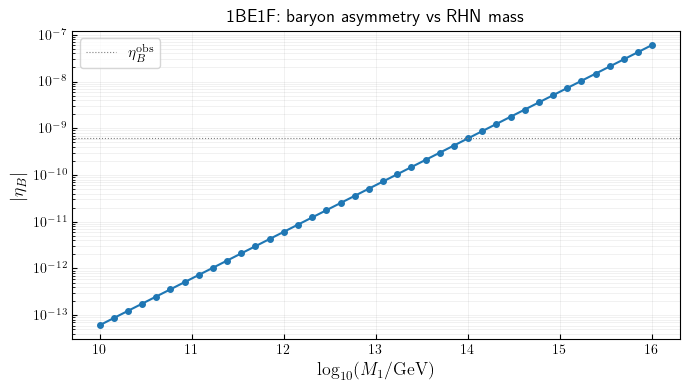

In [8]:
# Scan M1 for 1BE1F and plot eta_B vs M1
L_scan = ulysses.selectModel('1BE1F', zmin=0.1, zmax=100, zsteps=500, ordering=0, loop=False)

params_1BE1F = {
    'm'    : -100,   # effectively massless lightest neutrino
    'M1'   : 14,     # M1 = 10^14 GeV
    'M2'   : 15,
    'M3'   : 16,
    'delta': 270,
    'a21'  : 0,
    'a31'  : 0,
    'x1'   : 180,
    'y1'   : 1.4,
    'x2'   : 180,
    'y2'   : 11.2,
    'x3'   : 180,
    'y3'   : 11,
    't12'  : 33.82,
    't13'  : 8.61,
    't23'  : 49.7,
}

p = dict(params_1BE1F)   # copy
M1_vals  = np.linspace(10, 16, 40)
etaB_vals = []

for m1 in M1_vals:
    p['M1'] = m1
    p['M2'] = m1 + 1
    p['M3'] = m1 + 2
    etaB_vals.append(abs(L_scan(p)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(M1_vals, etaB_vals, 'o-', lw=1.5, ms=4)
ax.axhline(6.1e-10, color='grey', lw=0.8, ls=':', label=r"$\eta_B^{\rm obs}$")
ax.set_yscale('log')
ax.set_xlabel(r"$\log_{10}(M_1/\mathrm{GeV})$", fontsize=13)
ax.set_ylabel(r"$|\eta_B|$", fontsize=13)
ax.set_title("1BE1F: baryon asymmetry vs RHN mass", fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(direction='in', which='both')
ax.grid(which='both', ls='-', lw=0.4, color='grey', alpha=0.2)
plt.tight_layout()
plt.show()

---
## 6. Listing all available models

ULYSSES discovers models automatically — any subclass of `ULSBase` with a non-empty `shortname()` is registered.

In [9]:
import pandas as pd

models = ulysses.getBuiltInModels()
rows = []
for name, cls in sorted(models.items()):
    inst = cls.__new__(cls)  # don't call __init__, just inspect
    rows.append({'Model key': name, 'Class': cls.__name__})

pd.DataFrame(rows).set_index('Model key')

,Class
Model key,
1BE1F,EtaB_1BE1F
1BE1F_Case2,EtaB_1BE1F_Case2
1BE1F_Case3,EtaB_1BE1F_Case3
1BE1F_Case4,EtaB_1BE1F_Case4
1BE1F_CaseS2,EtaB_1BE1F_CaseS2
1BE1F_DM_FreezeIn,EtaB_1BE1F_DM_FreezeIn
1BE1F_PBH,EtaB_PBH
1BE1Fsf,EtaB_1BE1Fsf
1BE2F,EtaB_1BE2F
